# Radial Basis Function (RBF) interpolation

This notebook demonstrates **RBF interpolation** with `bluemath_tk` using two known theoretical surfaces. Because the exact value is available everywhere, interpolation errors can be measured directly.

## 1. Method

An RBF interpolator approximates a response from values known at scattered locations:

$$\hat{f}(x)=\sum_{i=1}^{N}w_i\,\phi\left(\lVert x-x_i\rVert\right),$$

where $x_i$ are the training locations, $w_i$ are fitted weights, and $\phi$ is a radial kernel. The influence of a training point depends only on distance. RBFs are useful for reconstructing smooth multidimensional responses from a limited set of simulations.

In [1]:
import numpy as np
import pandas as pd

from bluemath_tk.interpolation.rbf import RBF
from utils.plotting import plot_rbf_result

## 2. Reusable visualization

The shared `plot_rbf_result` helper, imported from `utils.plotting`, compares the exact theoretical surface, the sampled training points, the RBF reconstruction, and the pointwise error. Both examples use the same color scale for the exact and reconstructed values.

## 3. Quadratic surface

The first theoretical model is

$$z=x^2+y^2, \qquad (x,y)\in[0,1]^2.$$

Only 30 locations are sampled from the exact surface. A fixed random seed and sampling without replacement make the experiment reproducible and avoid duplicate training points.

In [3]:
rng = np.random.default_rng(seed=0)
n_disc = 100
x_grid, y_grid = np.meshgrid(
    np.linspace(0, 1, n_disc),
    np.linspace(0, 1, n_disc),
)
z_exact = x_grid**2 + y_grid**2

dataset = pd.DataFrame({"x": x_grid.ravel(), "y": y_grid.ravel()})
exact_values = z_exact.ravel()
sample_indices = rng.choice(len(dataset), size=30, replace=False)
subset = dataset.iloc[sample_indices].reset_index(drop=True)
target = pd.DataFrame({"z": exact_values[sample_indices]})
sample = subset.assign(z=target["z"])

### Fit and predict

The interpolator is fitted with the scattered $(x,y,z)$ samples and evaluated over the complete regular grid.

### Arguments used in `fit_predict`

- `subset_data`: input coordinates where the response is already known. Here it contains the sampled `x` and `y`; every row corresponds to the same row in `target_data`.
- `subset_directional_variables`: input columns containing circular directions. It is empty because Cartesian `x` and `y` are linear variables.
- `target_data`: known responses used to fit the interpolator. Here it contains the theoretical value `z` at each sampled coordinate.
- `target_directional_variables`: output columns that are circular. It is empty because `z` is a scalar, not an angle.
- `normalize_target_data`: rescales the target while fitting and converts predictions back afterwards. `True` is convenient when target variables have different numerical magnitudes.
- `dataset`: all input locations where predictions are requested. It must contain the same input columns as `subset_data`; here it is the complete regular grid.
- `num_workers`: number of parallel workers used during parameter optimization. Increasing it can reduce fitting time when CPU resources are available.
- `iteratively_update_sigma`: if `True`, the kernel-width parameter $\sigma$ is refined iteratively. This can improve the fit at additional computational cost.

The method fits and predicts in one call, returning a `DataFrame` with one interpolated response for every row in `dataset`. The Mexican-hat example below uses the same arguments with a larger training subset.

In [4]:
rbf = RBF()
quadratic_predictions = rbf.fit_predict(
    subset_data=subset,
    subset_directional_variables=[],
    target_data=target,
    target_directional_variables=[],
    normalize_target_data=True,
    dataset=dataset,
    num_workers=4,
    iteratively_update_sigma=True,
)

quadratic_rmse = np.sqrt(
    np.mean((quadratic_predictions["z"].to_numpy() - exact_values) ** 2)
)
print(f"Quadratic-surface RMSE: {quadratic_rmse:.6f}")

Quadratic-surface RMSE: 0.036873


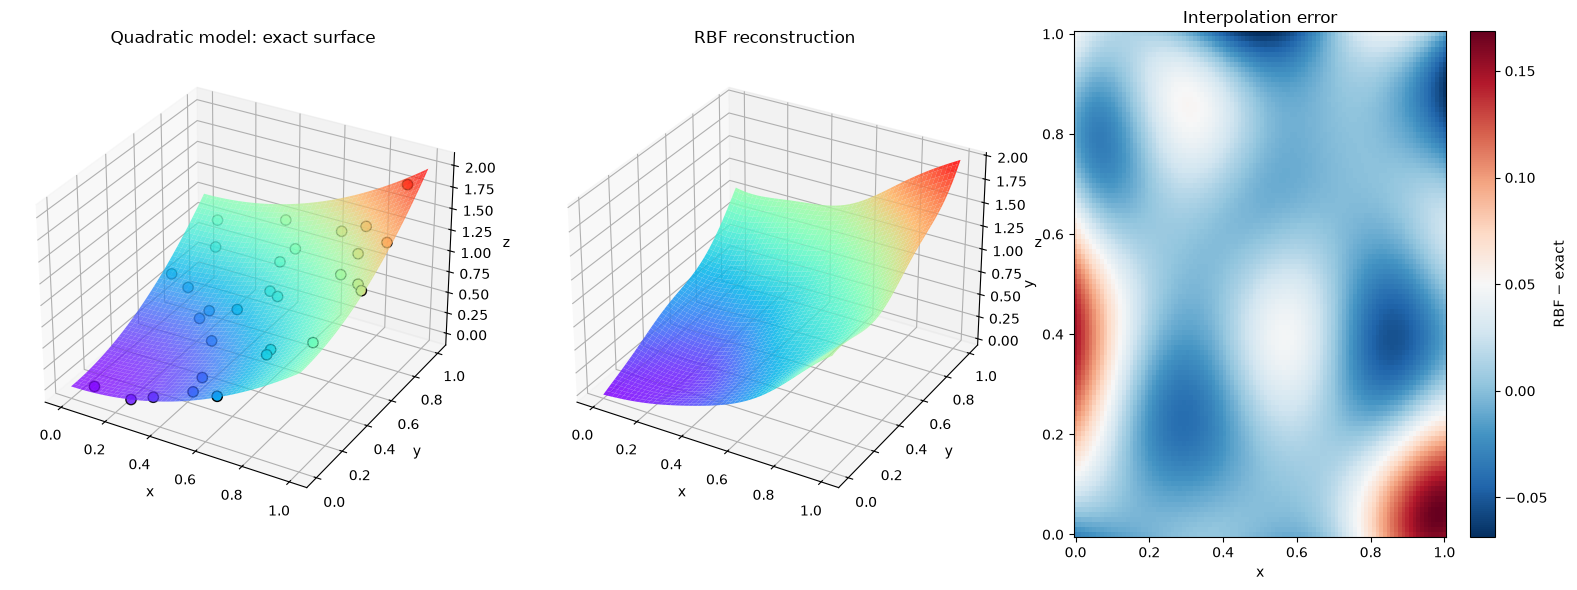

In [5]:
plot_rbf_result(
    x_grid,
    y_grid,
    z_exact,
    sample,
    quadratic_predictions["z"].to_numpy(),
    title="Quadratic model",
)

## 4. Mexican-hat surface

The second model is more oscillatory:

$$z=\frac{\sin(r)}{r}, \qquad r=\sqrt{x^2+y^2}.$$

At $r=0$ the limiting value is 1. The implementation uses `np.sinc(r/π)`, which evaluates this limit safely. A larger training set is used because the surface contains several peaks and troughs.

In [6]:
n_disc = 100
x_grid_hat, y_grid_hat = np.meshgrid(
    np.linspace(-8, 8, n_disc),
    np.linspace(-8, 8, n_disc),
)
radius = np.sqrt(x_grid_hat**2 + y_grid_hat**2)
z_exact_hat = np.sinc(radius / np.pi)

dataset_hat = pd.DataFrame(
    {"x": x_grid_hat.ravel(), "y": y_grid_hat.ravel()}
)
exact_values_hat = z_exact_hat.ravel()
sample_indices_hat = rng.choice(len(dataset_hat), size=200, replace=False)
subset_hat = dataset_hat.iloc[sample_indices_hat].reset_index(drop=True)
target_hat = pd.DataFrame({"z": exact_values_hat[sample_indices_hat]})
sample_hat = subset_hat.assign(z=target_hat["z"])

In [7]:
rbf_hat = RBF()
hat_predictions = rbf_hat.fit_predict(
    subset_data=subset_hat,
    subset_directional_variables=[],
    target_data=target_hat,
    target_directional_variables=[],
    normalize_target_data=True,
    dataset=dataset_hat,
    num_workers=4,
    iteratively_update_sigma=True,
)

hat_rmse = np.sqrt(
    np.mean((hat_predictions["z"].to_numpy() - exact_values_hat) ** 2)
)
print(f"Mexican-hat RMSE: {hat_rmse:.6f}")

Mexican-hat RMSE: 0.003146


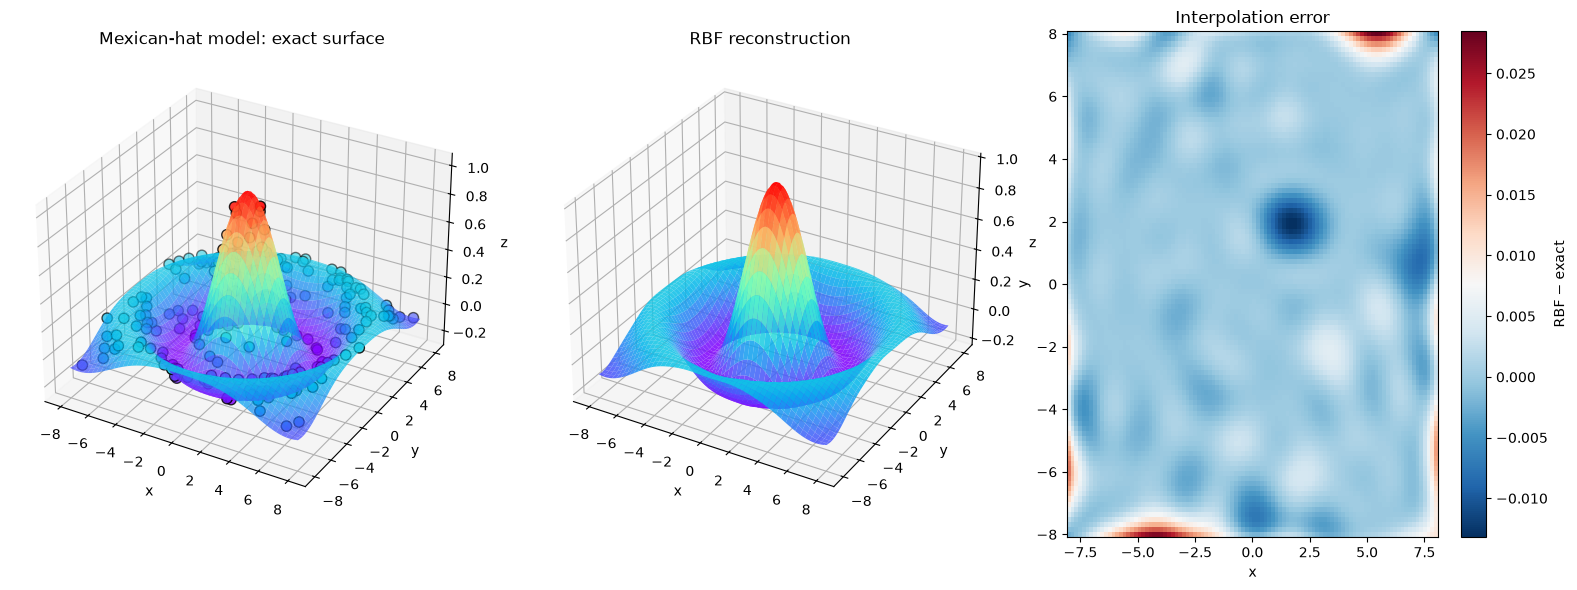

In [8]:
plot_rbf_result(
    x_grid_hat,
    y_grid_hat,
    z_exact_hat,
    sample_hat,
    hat_predictions["z"].to_numpy(),
    title="Mexican-hat model",
)

## 5. Compare reconstruction errors

The Root Mean Square Error summarizes the discrepancy over every grid point:

$$\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{z}_i-z_i)^2}.$$

The Mexican-hat case is generally harder because its curvature changes across the domain. Accuracy depends on the number and spatial distribution of training points, as well as the fitted radial-kernel width.

In [9]:
pd.DataFrame(
    {
        "Surface": ["Quadratic", "Mexican hat"],
        "Training points": [len(subset), len(subset_hat)],
        "RMSE": [quadratic_rmse, hat_rmse],
    }
).style.format({"RMSE": "{:.6f}"}).hide(axis="index")

Surface,Training points,RMSE
Quadratic,30,0.036873
Mexican hat,200,0.003146


## Summary

RBF reconstructed two continuous theoretical surfaces from sparse scattered samples. The exact equations made it possible to map local errors and calculate RMSE. The smooth quadratic model illustrates the basic method, while the Mexican-hat model shows the additional sampling demands of an oscillatory response.